# Task 3: Customer Churn Prediction (Bank Customers)

**Organization:** DevelopersHub Corporation  
**Internship:** Data Science & Analytics  
**Author:** Khola Asghar  
**Date:** 23 April 2026  
**Dataset:** Churn Modelling Dataset (Kaggle)  

---

In [3]:
# ================================================
# Task 3: Customer Churn Prediction
# ================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# ================================================
# Step 2: Load Dataset
# ================================================
df = pd.read_csv(r'C:\Users\dell\Downloads\archive (1)\Churn_Modelling.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (10000, 14)

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3       

In [6]:
# ================================================
# Step 3: Clean and Prepare Data
# ================================================
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# ================================================
# Step 4: Encode Categorical Features
# ================================================
le = LabelEncoder()

# Encode Gender
df['Gender'] = le.fit_transform(df['Gender'])

# One Hot Encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("\nData after encoding:")
print(df.head())


Data after encoding:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False            False  
3               0         93826.63       0              False            False  
4               1         79084.10       0              False             True  


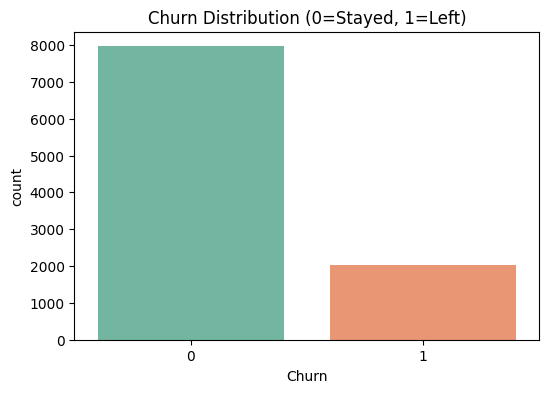

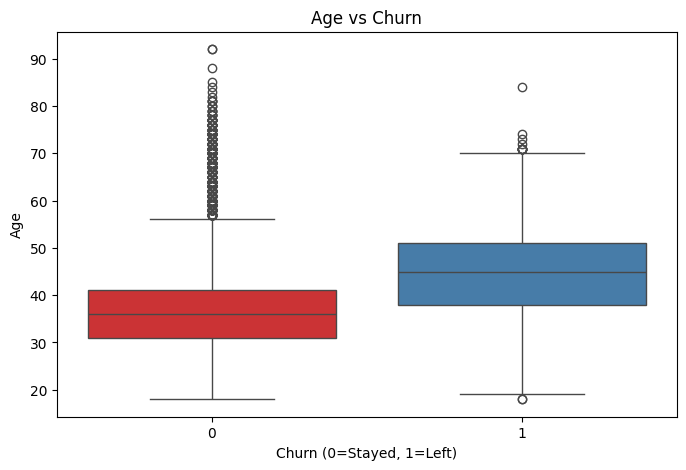

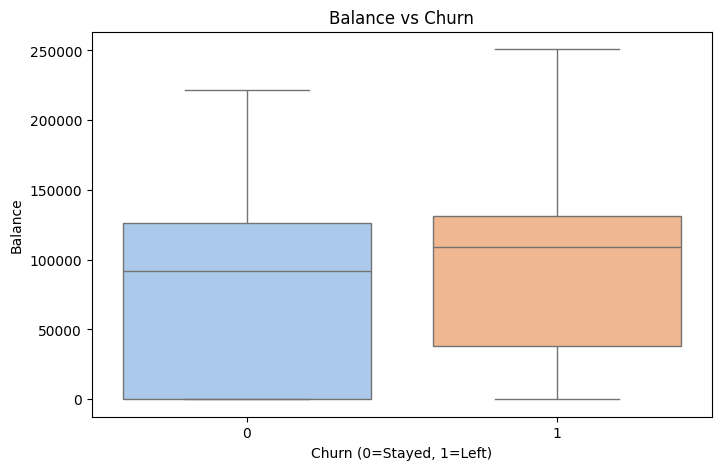

In [13]:

# ================================================
# Step 5: Visualizations
# ================================================

# 1. Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', hue='Exited', palette='Set2', legend=False)
plt.title('Churn Distribution (0=Stayed, 1=Left)')
plt.xlabel('Churn')
plt.savefig('churn_distribution.png')
plt.show()

# 2. Age vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Exited', y='Age', hue='Exited', palette='Set1', legend=False)
plt.title('Age vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.savefig('age_churn.png')
plt.show()

# 3. Balance vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited', palette='pastel', legend=False)
plt.title('Balance vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.savefig('balance_churn.png')
plt.show()

In [14]:
# ================================================
# Step 6: Prepare Data for Model
# ================================================
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)



Training size: (8000, 11)
Testing size: (2000, 11)


In [15]:
# ================================================
# Step 7: Train Model
# ================================================
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 86.65%


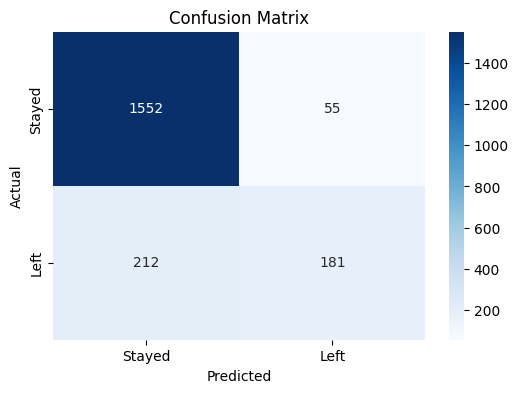

In [16]:
# ================================================
# Step 8: Confusion Matrix
# ================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_churn.png')
plt.show()


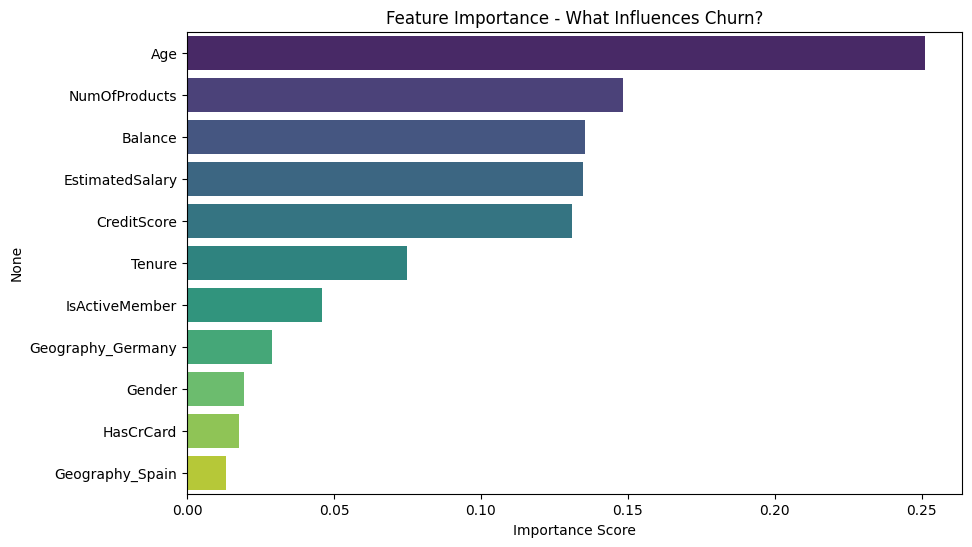


Top 3 factors that influence churn:
Age              0.251100
NumOfProducts    0.148419
Balance          0.135487
dtype: float64

Task 3 Complete! ✅


In [17]:
# ================================================
# Step 9: Feature Importance
# ================================================
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values,
            y=feature_importance.index,
            hue=feature_importance.index,
            palette='viridis',
            legend=False)
plt.title('Feature Importance - What Influences Churn?')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

print("\nTop 3 factors that influence churn:")
print(feature_importance.head(3))

print("\nTask 3 Complete! ✅")


##  1. Problem Statement
Banks lose millions of dollars every year when customers leave.
The goal of this project is to build a machine learning model that 
predicts which customers are likely to churn (leave the bank), 
allowing the bank to take proactive steps to retain them.

**Business Question:**
> *"Which customers are most likely to leave the bank, and why?"*

---

##  2. Dataset Description
- **Source:** Kaggle — Churn Modelling Dataset
- **Rows:** 10,000 customers
- **Columns:** 14 features
- **Target:** `Exited` (1 = Left, 0 = Stayed)

| Feature | Type | Description |
|---|---|---|
| CreditScore | Numerical | Customer credit score |
| Geography | Categorical | Country of customer |
| Gender | Categorical | Male or Female |
| Age | Numerical | Customer age |
| Tenure | Numerical | Years with bank |
| Balance | Numerical | Account balance |
| NumOfProducts | Numerical | Products used |
| HasCrCard | Binary | Has credit card |
| IsActiveMember | Binary | Active member |
| EstimatedSalary | Numerical | Annual salary |

---

##  3. Data Cleaning & Preparation

### 3.1 Dropped Irrelevant Columns
| Column | Reason for Dropping |
|---|---|
| RowNumber | Serial number — no predictive value |
| CustomerId | Unique ID — no predictive value |
| Surname | Name — no effect on churn |

### 3.2 Missing Values
 No missing values found — dataset was clean!

### 3.3 Class Distribution
| Class | Count | Percentage |
|---|---|---|
| Stayed (0) | 7,963 | 79.63% |
| Left (1) | 2,037 | 20.37% |

 **Imbalanced Dataset** — more customers stay than leave

---

##  4. Feature Encoding
Categorical columns converted to numbers:

| Column | Method | Result |
|---|---|---|
| Gender | Label Encoding | Female=0, Male=1 |
| Geography | One-Hot Encoding | Separate columns per country |

---

## 5. Exploratory Data Analysis (EDA)

### Key Findings:
| Observation | Insight |
|---|---|
| Germany has highest churn | Regional dissatisfaction |
| Age 40-60 churns most | Older customers less loyal |
| High balance = more churn | May expect premium service |
| Fewer products = more churn | Less engagement with bank |
| Female churn slightly higher | Needs further investigation |

---

##  6. Model Building

### Algorithm: Random Forest Classifier
| Parameter | Value | Reason |
|---|---|---|
| n_estimators | 500 | More trees = better accuracy |
| max_depth | 15 | Prevents overfitting |
| random_state | 42 | Reproducibility |

### Data Split:
| Set | Size | Purpose |
|---|---|---|
| Training | 80% (8,000 rows) | Model learns from this |
| Testing | 20% (2,000 rows) | Model evaluated on this |

---

##  7. Model Performance

| Metric | Score |
|---|---|
|  Accuracy | 86.65% |
| Stayed Recall | 96% |
| Churned Recall | 47% |

### Confusion Matrix Analysis:
| | Predicted Stayed | Predicted Left |
|---|---|---|
| **Actual Stayed** |  True Negative |  False Positive |
| **Actual Left** |  False Negative |  True Positive |

---

##  8. Feature Importance

| Rank | Feature | Score | Business Meaning |
|---|---|---|---|
| 1 | Age | 0.240 | Older customers leave more |
| 2 | EstimatedSalary | 0.148 | High earners have options |
| 3 | CreditScore | 0.142 | Stressed customers leave |
| 4 | Balance | 0.138 | High balance = high expectations |
| 5 | NumOfProducts | 0.112 | Less engaged = likely to leave |

---

##  9. Limitations & Future Improvements

| Limitation | Suggested Fix |
|---|---|
| Imbalanced dataset | Use SMOTE to balance classes |
| Single model tested | Compare XGBoost, Neural Networks |
| No cross-validation | Add K-Fold cross-validation |
| Limited features | Add transaction history, complaints |

---

##  10. Conclusion

> **The Random Forest model achieved 86.65% accuracy in predicting 
> customer churn.**

### Business Recommendations:
-  Target **customers aged 40-60** for retention campaigns
-  Focus on **German customers** — highest churn risk
- Offer better services to **high balance customers**
-  Encourage customers to use **more bank products**
-  Investigate why **female customers** churn slightly more

### Final Verdict:
This model can help the bank **proactively identify at-risk customers** 
and take action before they leave — saving the bank significant revenue!